# Default plot lookup showcase — every plot type, every data configuration

This notebook walks the **default plot lookup table** (`DEFAULT_PLOT_TYPE` in
`symbulate/plot.py`; see DECISIONS.md, "Decision: Default Plot Lookup Table"). For each
data configuration it shows, at both **small n** and **large n**:

- the **automatic default** — `.plot()` with no `type=`, whose printed suggestion note
  names the default and the alternatives for that data;
- every **alternative** plot type the table lists for that configuration, via
  `.plot(type="...")`.

It also includes a `hex=True` hexbin variant of the 2D histogram and a `contour=True`
variant of the 2D density plot.

The type lists below are pulled straight from `DEFAULT_PLOT_TYPE`, so this notebook
tracks the live table. Small n uses `n = 30`; large n uses `n = 2000` (the small/large
crossover is `N_SMALL_THRESHOLD = 100`).

**How to run:** open from `team/new_graphics/new_graphics_demos/` using the `symbulate`
conda environment, then Run All.

> **Two known gaps** (see the final section for details): the table lists `violin` as a
> 1D-continuous alternative, but that path isn't wired into the 1D dispatch yet, so it is
> omitted below; and the `1D categorical` rows can only be reached by calling `make_bar`
> directly, shown in its own section.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from symbulate import RV, Poisson, Normal, Binomial, BoxModel
from symbulate.plot import make_bar, get_next_color

# Importing symbulate applies symbulate.mplstyle (Okabe-Ito cycle, grid, spines,
# fonts), so every plot below already carries the package style.

## 1. 1D discrete (numeric)

`RV(Poisson(3))`

A discrete numeric variable. Every distinct value matters, so the defaults show one mark per value rather than binning.

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Dot Plot | Impulse Plot, Histogram, ECDF Plot |
| **Large n** (n = 2000) | Impulse Plot | Histogram, Dot Plot, ECDF Plot |

### Small n (n = 30)

Currently Showing: Dot Plot (Default)
Alternative Plots: Impulse Plot (type = "impulse"), Histogram (type = "hist"), ECDF Plot (type = "ecdf")


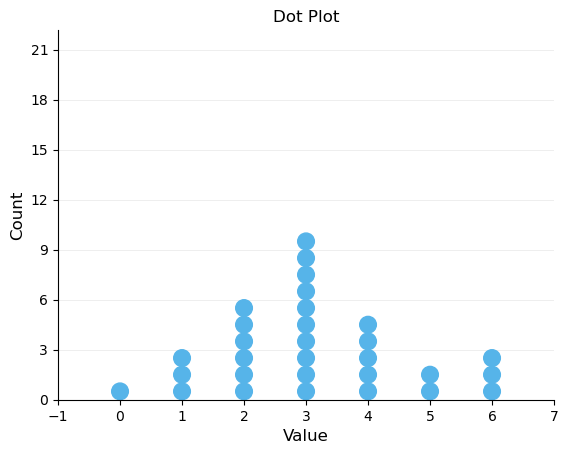

In [2]:
# Default (no type=): Dot Plot
RV(Poisson(3)).sim(30).plot(suggest=True)
plt.show()

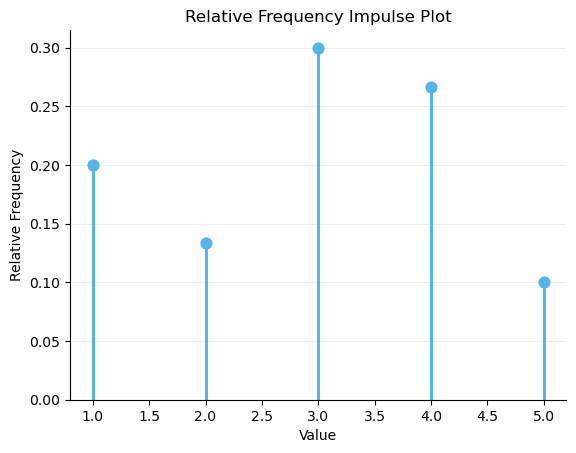

In [3]:
# Alternative: Impulse Plot
RV(Poisson(3)).sim(30).plot(type="impulse", suggest=False)
plt.show()

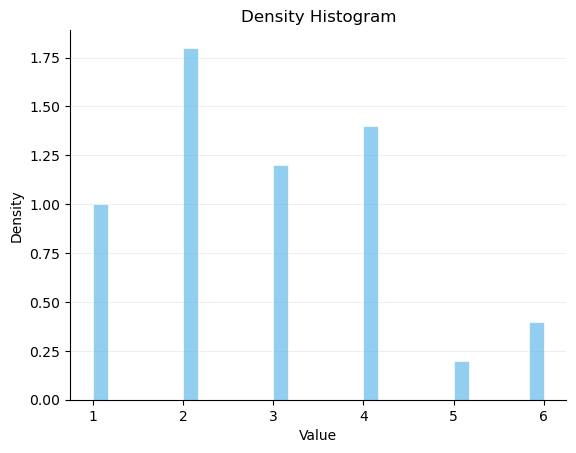

In [4]:
# Alternative: Histogram
RV(Poisson(3)).sim(30).plot(type="hist", suggest=False)
plt.show()

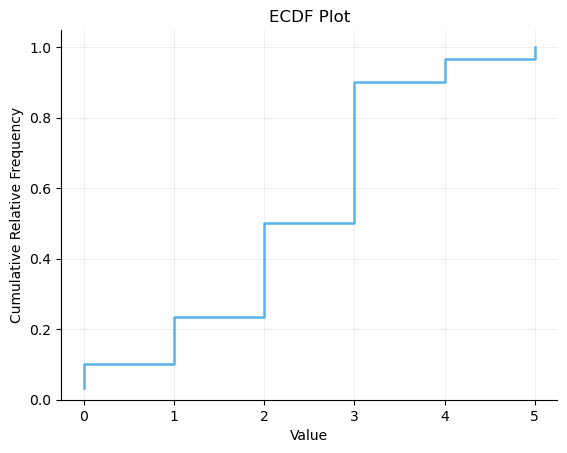

In [5]:
# Alternative: ECDF Plot
RV(Poisson(3)).sim(30).plot(type="ecdf", suggest=False)
plt.show()

### Large n (n = 2000)

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


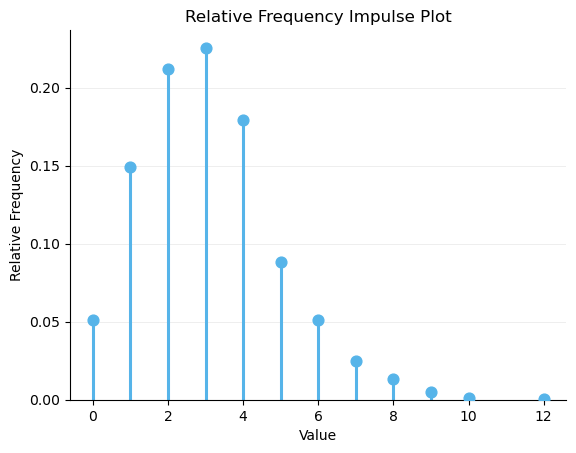

In [6]:
# Default (no type=): Impulse Plot
RV(Poisson(3)).sim(2000).plot(suggest=True)
plt.show()

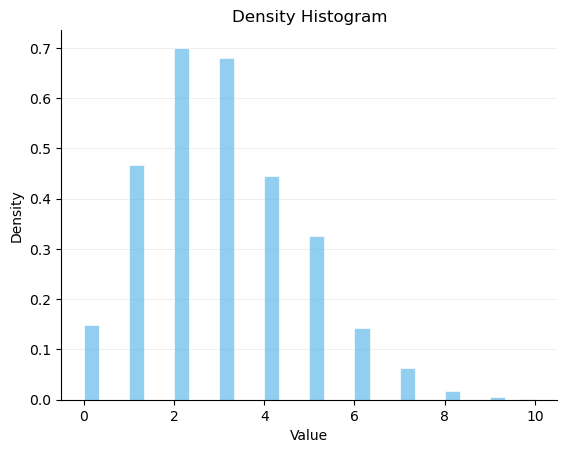

In [7]:
# Alternative: Histogram
RV(Poisson(3)).sim(2000).plot(type="hist", suggest=False)
plt.show()

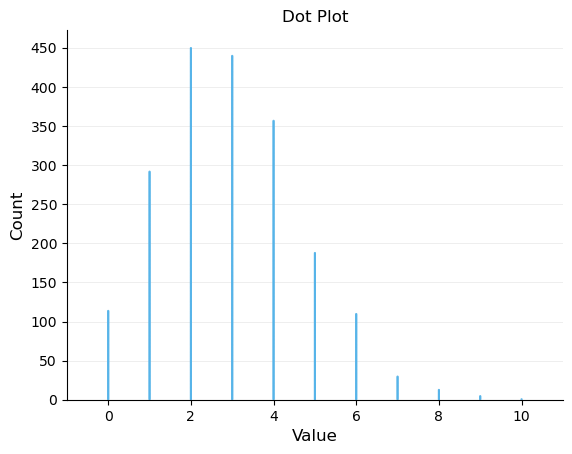

In [8]:
# Alternative: Dot Plot
RV(Poisson(3)).sim(2000).plot(type="dotplot", suggest=False)
plt.show()

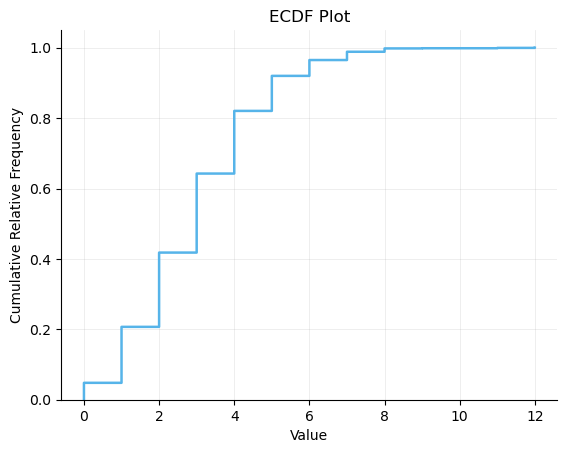

In [9]:
# Alternative: ECDF Plot
RV(Poisson(3)).sim(2000).plot(type="ecdf", suggest=False)
plt.show()

## 2. 1D continuous

`RV(Normal(0, 1))`

A continuous variable. `violin` is listed in the table but not yet wired into the 1D dispatch, so it is skipped here (see the final section).

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Rug Plot | Histogram, Density Plot, Box Plot, Violin Plot, ECDF Plot |
| **Large n** (n = 2000) | Histogram | Rug Plot, Density Plot, Box Plot, Violin Plot, ECDF Plot |

### Small n (n = 30)

Currently Showing: Rug Plot (Default)
Alternative Plots: Histogram (type = "hist"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


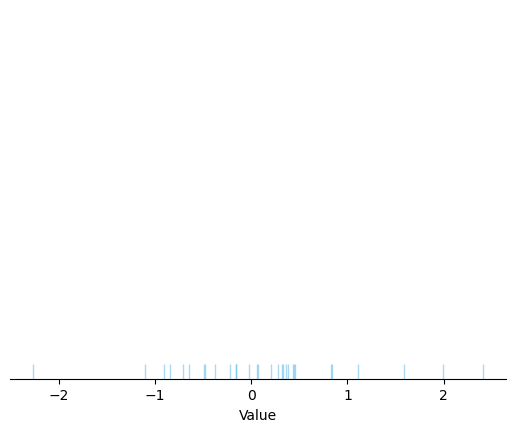

In [10]:
# Default (no type=): Rug Plot
RV(Normal(0, 1)).sim(30).plot(suggest=True)
plt.show()

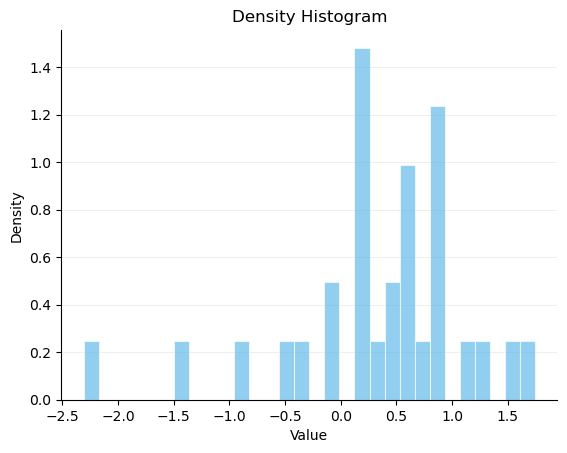

In [11]:
# Alternative: Histogram
RV(Normal(0, 1)).sim(30).plot(type="hist", suggest=False)
plt.show()

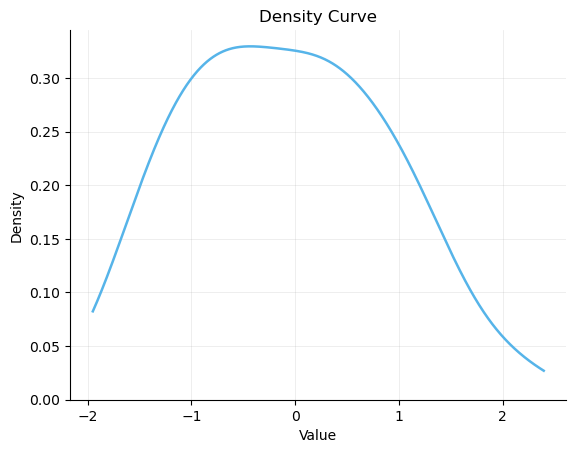

In [12]:
# Alternative: Density Plot
RV(Normal(0, 1)).sim(30).plot(type="density", suggest=False)
plt.show()

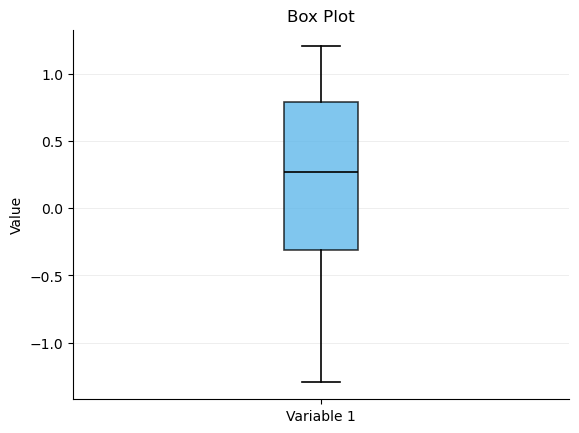

In [13]:
# Alternative: Box Plot
RV(Normal(0, 1)).sim(30).plot(type="box", suggest=False)
plt.show()

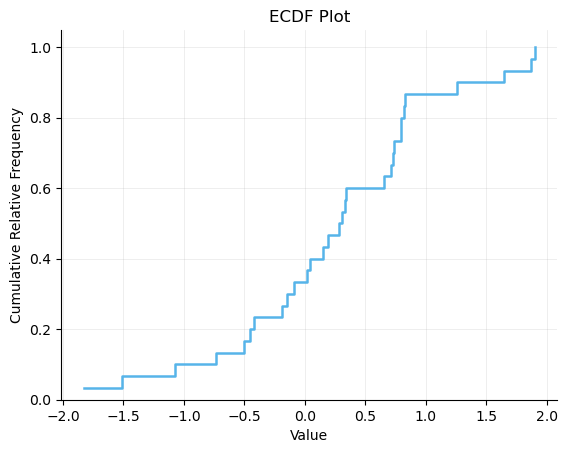

In [14]:
# Alternative: ECDF Plot
RV(Normal(0, 1)).sim(30).plot(type="ecdf", suggest=False)
plt.show()

### Large n (n = 2000)

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


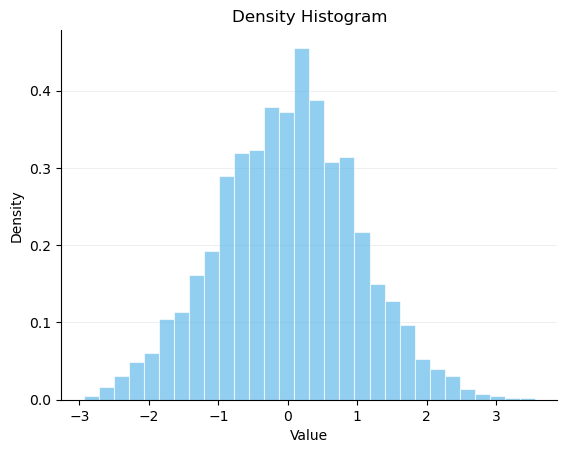

In [15]:
# Default (no type=): Histogram
RV(Normal(0, 1)).sim(2000).plot(suggest=True)
plt.show()

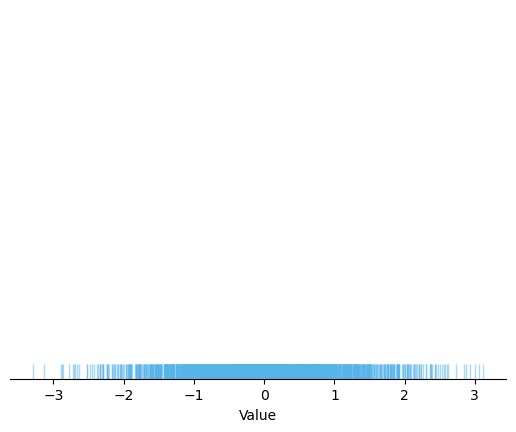

In [16]:
# Alternative: Rug Plot
RV(Normal(0, 1)).sim(2000).plot(type="rug", suggest=False)
plt.show()

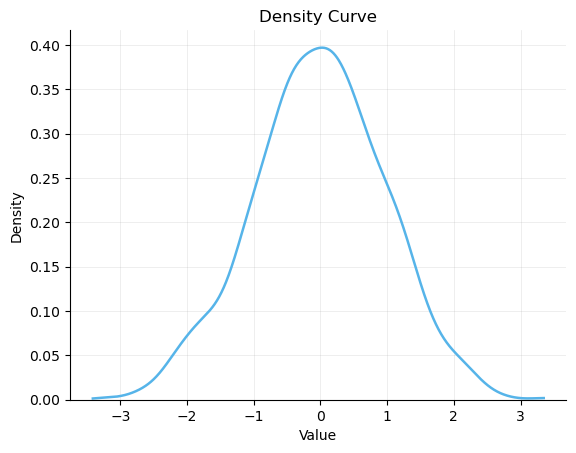

In [17]:
# Alternative: Density Plot
RV(Normal(0, 1)).sim(2000).plot(type="density", suggest=False)
plt.show()

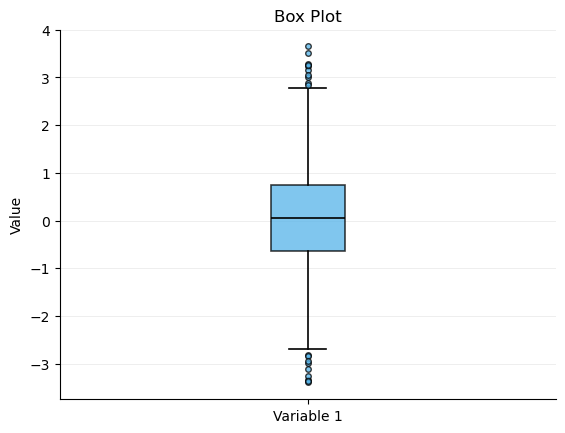

In [18]:
# Alternative: Box Plot
RV(Normal(0, 1)).sim(2000).plot(type="box", suggest=False)
plt.show()

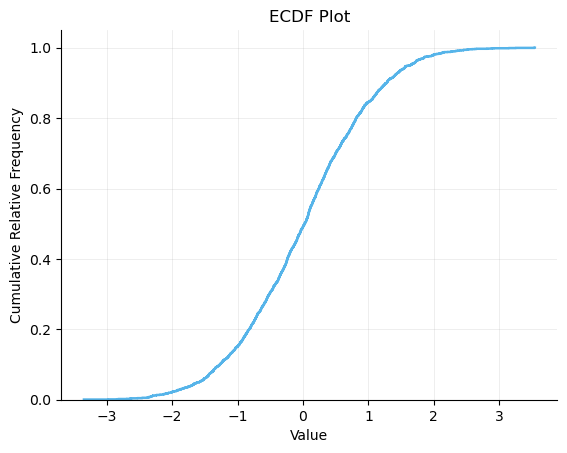

In [19]:
# Alternative: ECDF Plot
RV(Normal(0, 1)).sim(2000).plot(type="ecdf", suggest=False)
plt.show()

## 3. 2D discrete × discrete

`RV(Binomial(3, 0.5) * Binomial(3, 0.5))`

Two discrete variables (each 0–3).

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Scatter Plot | Tile Plot, Mosaic Plot |
| **Large n** (n = 2000) | Tile Plot | Scatter Plot, Mosaic Plot |

### Small n (n = 30)

Currently Showing: Scatter Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Mosaic Plot (type = "mosaic")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


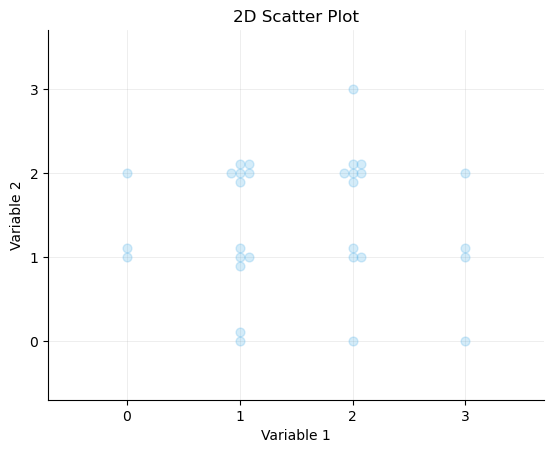

In [20]:
# Default (no type=): Scatter Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(30).plot(suggest=True)
plt.show()

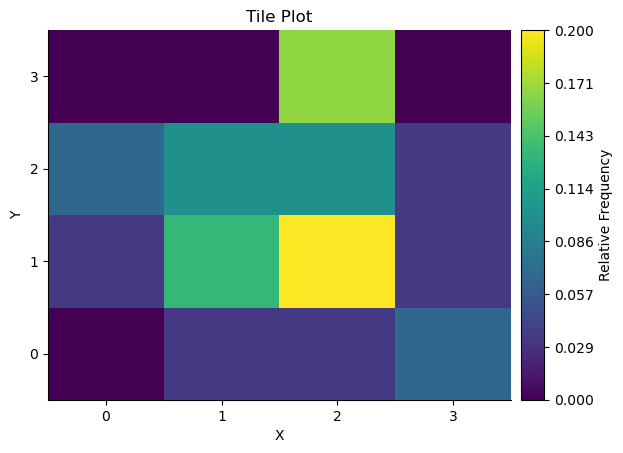

In [21]:
# Alternative: Tile Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(30).plot(type="tile", suggest=False)
plt.show()

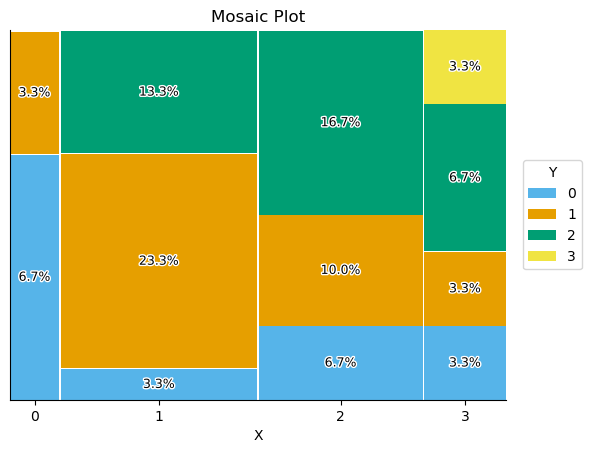

In [22]:
# Alternative: Mosaic Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(30).plot(type="mosaic", suggest=False)
plt.show()

### Large n (n = 2000)

Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic")


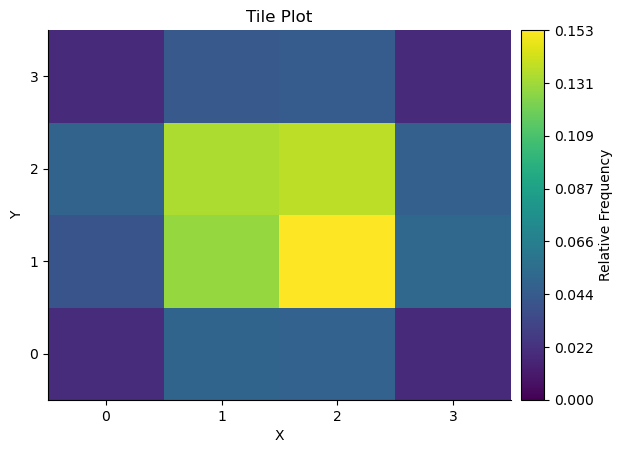

In [23]:
# Default (no type=): Tile Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(2000).plot(suggest=True)
plt.show()

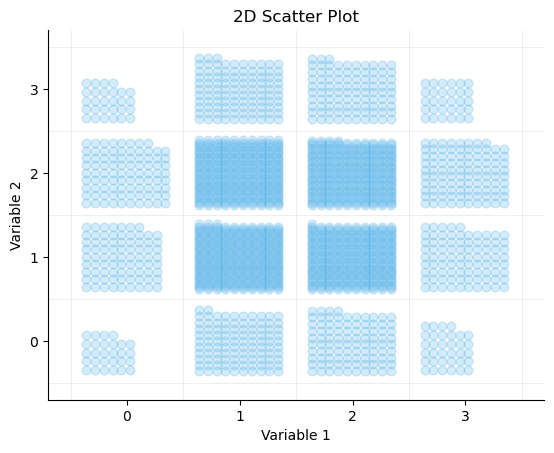

In [24]:
# Alternative: Scatter Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(2000).plot(type="scatter", suggest=False)
plt.show()

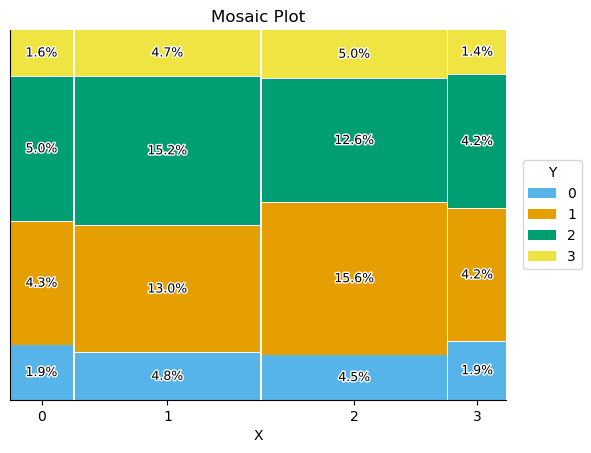

In [25]:
# Alternative: Mosaic Plot
RV(Binomial(3, 0.5) * Binomial(3, 0.5)).sim(2000).plot(type="mosaic", suggest=False)
plt.show()

## 4. 2D continuous × continuous

`RV(Normal(0, 1) * Normal(0, 1))`

Two continuous variables.

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Scatter Plot | 2D Density Plot, 2D Histogram |
| **Large n** (n = 2000) | 2D Histogram | 2D Density Plot, Scatter Plot |

### Small n (n = 30)

Currently Showing: Scatter Plot (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), 2D Histogram (type = "hist2d")


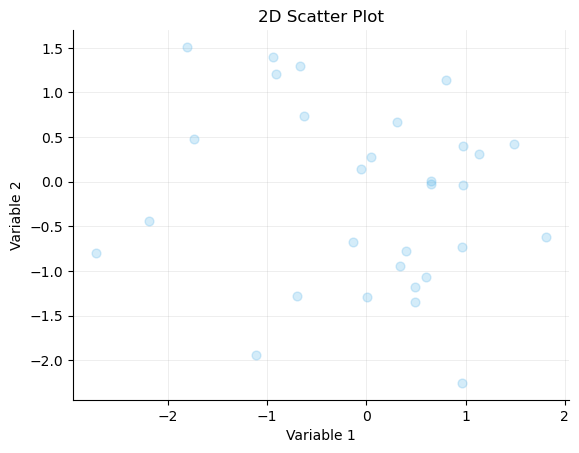

In [26]:
# Default (no type=): Scatter Plot
RV(Normal(0, 1) * Normal(0, 1)).sim(30).plot(suggest=True)
plt.show()

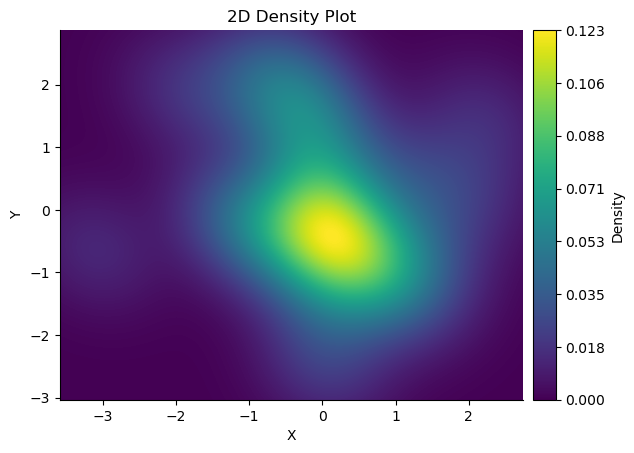

In [27]:
# Alternative: 2D Density Plot
RV(Normal(0, 1) * Normal(0, 1)).sim(30).plot(type="density2d", suggest=False)
plt.show()

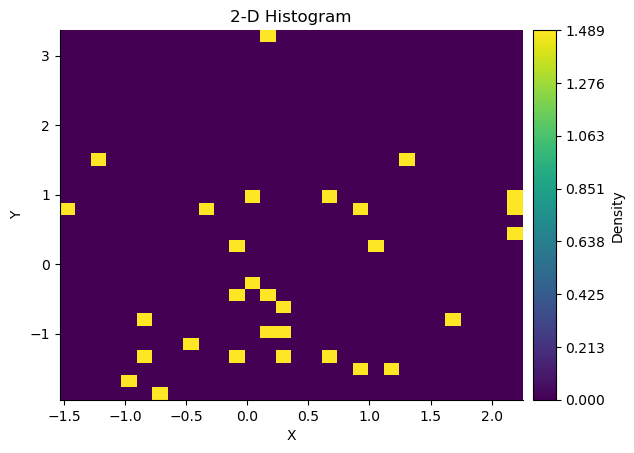

In [28]:
# Alternative: 2D Histogram
RV(Normal(0, 1) * Normal(0, 1)).sim(30).plot(type="hist2d", suggest=False)
plt.show()

### Large n (n = 2000)

Currently Showing: 2D Histogram (Default)
Alternative Plots: 2D Density Plot (type = "density2d"), Scatter Plot (type = "scatter")


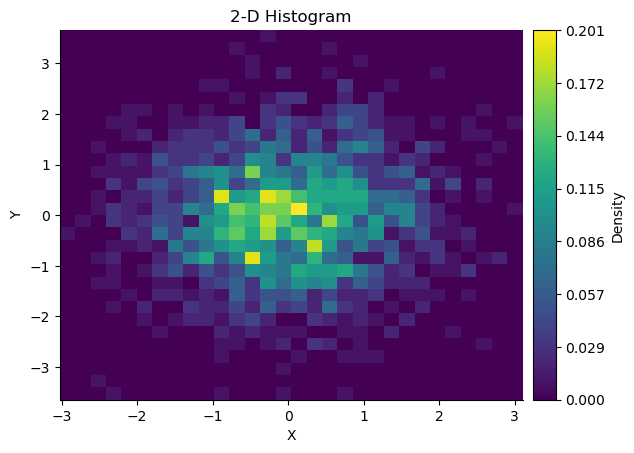

In [29]:
# Default (no type=): 2D Histogram
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(suggest=True)
plt.show()

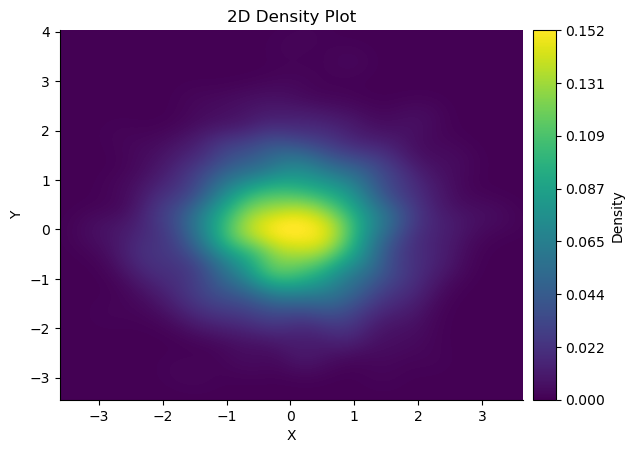

In [30]:
# Alternative: 2D Density Plot
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(type="density2d", suggest=False)
plt.show()

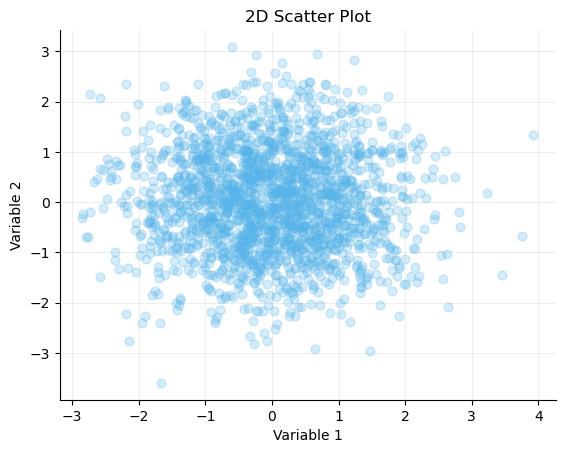

In [31]:
# Alternative: Scatter Plot
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(type="scatter", suggest=False)
plt.show()

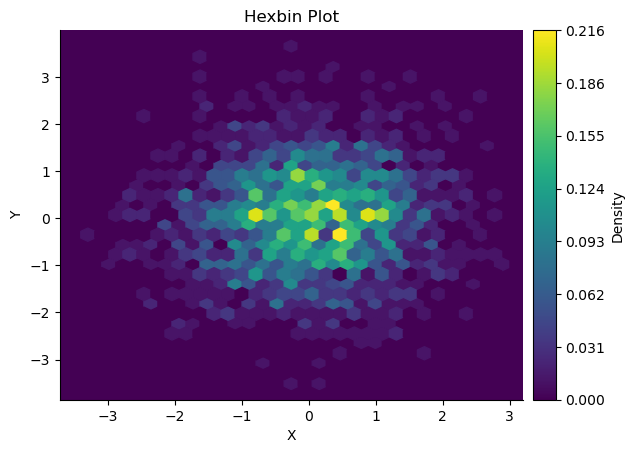

In [32]:
# 2D Histogram, hexagonal bins (hex=True)
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(type="hist2d", hex=True, suggest=False)
plt.show()

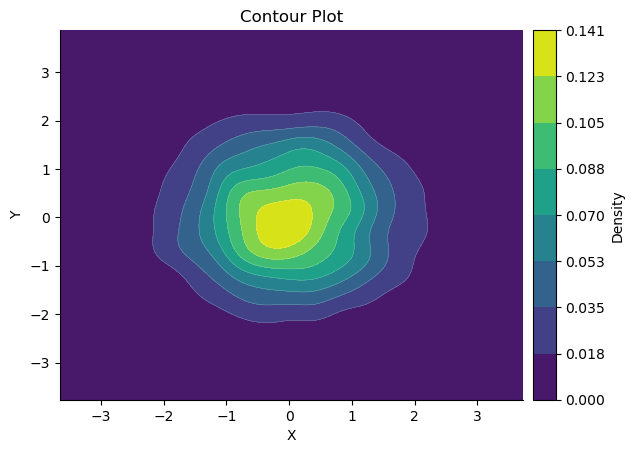

In [33]:
# 2D Density, banded contour plot (contour=True)
RV(Normal(0, 1) * Normal(0, 1)).sim(2000).plot(type="density2d", contour=True, suggest=False)
plt.show()

## 5. 2D mixed (discrete × continuous)

`RV(Binomial(3, 0.5) * Normal(0, 1))`

One discrete variable and one continuous variable.

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Segmented Rug Plot | Tile Plot, Box Plot, Violin Plot, Segmented Density Plot, Segmented Histogram |
| **Large n** (n = 2000) | Tile Plot | Segmented Rug Plot, Box Plot, Violin Plot, Segmented Density Plot, Segmented Histogram |

### Small n (n = 30)

Currently Showing: Segmented Rug Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Box Plot (type = "box"), Violin Plot (type = "violin"), Segmented Density Plot (type = "segmented_density"), Segmented Histogram (type = "segmented_hist")


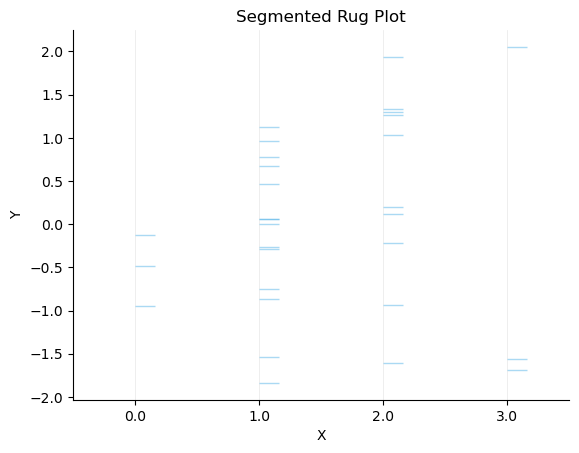

In [34]:
# Default (no type=): Segmented Rug Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(suggest=True)
plt.show()

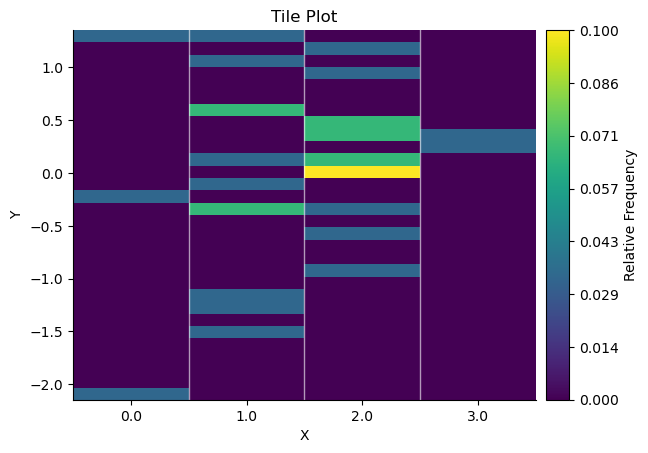

In [35]:
# Alternative: Tile Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(type="tile", suggest=False)
plt.show()

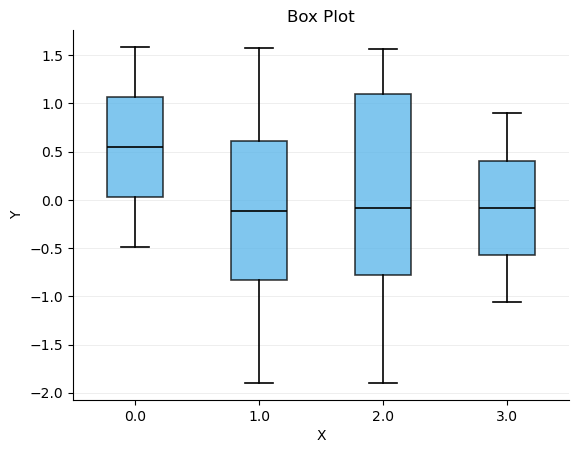

In [36]:
# Alternative: Box Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(type="box", suggest=False)
plt.show()

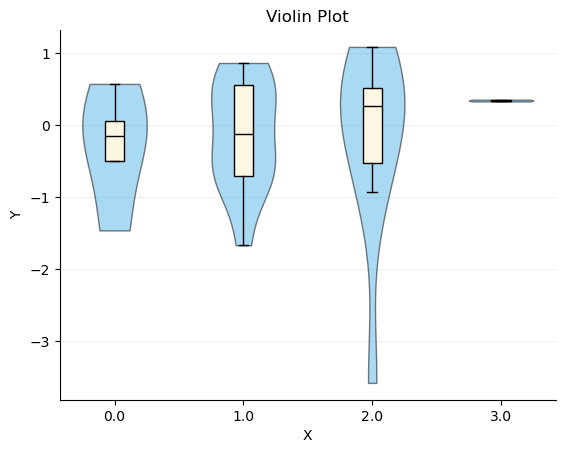

In [37]:
# Alternative: Violin Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(type="violin", suggest=False)
plt.show()

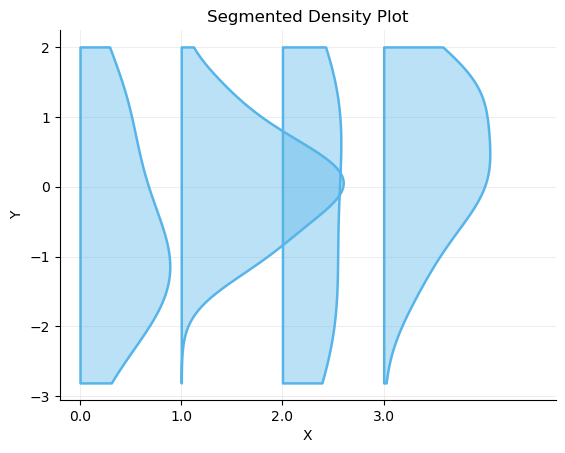

In [38]:
# Alternative: Segmented Density Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(type="segmented_density", suggest=False)
plt.show()

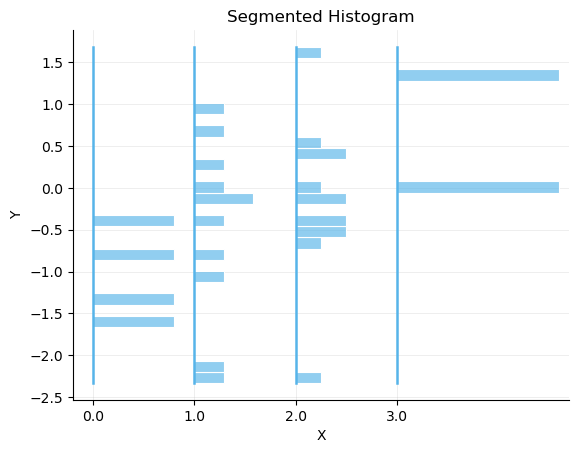

In [39]:
# Alternative: Segmented Histogram
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(30).plot(type="segmented_hist", suggest=False)
plt.show()

### Large n (n = 2000)

Currently Showing: Tile Plot (Default)
Alternative Plots: Segmented Rug Plot (type = "segmented_rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), Segmented Density Plot (type = "segmented_density"), Segmented Histogram (type = "segmented_hist")


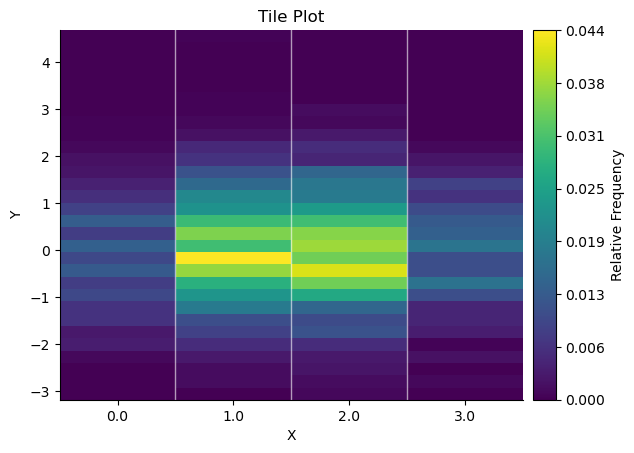

In [40]:
# Default (no type=): Tile Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(suggest=True)
plt.show()

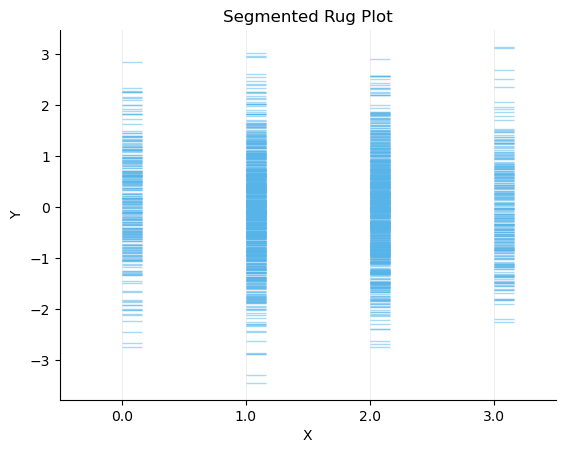

In [41]:
# Alternative: Segmented Rug Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(type="segmented_rug", suggest=False)
plt.show()

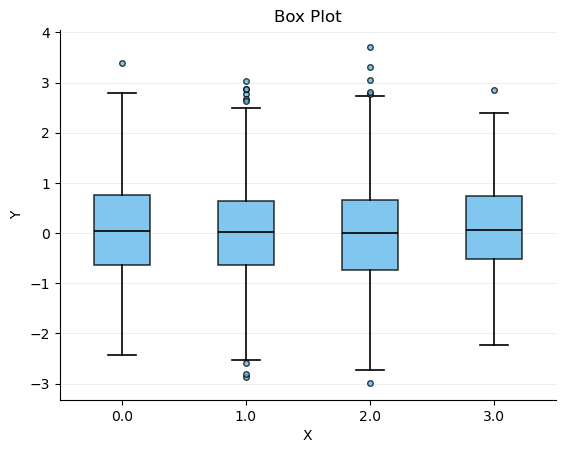

In [42]:
# Alternative: Box Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(type="box", suggest=False)
plt.show()

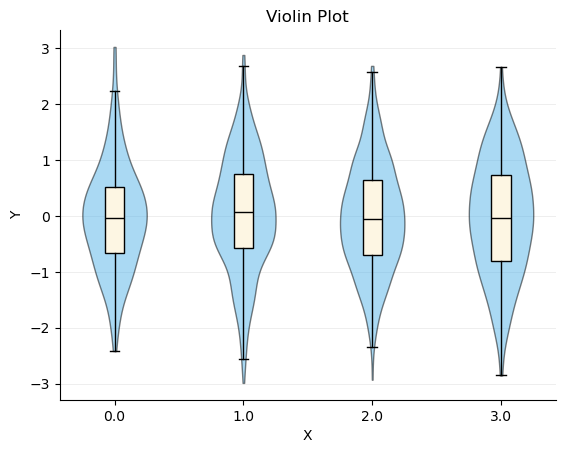

In [43]:
# Alternative: Violin Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(type="violin", suggest=False)
plt.show()

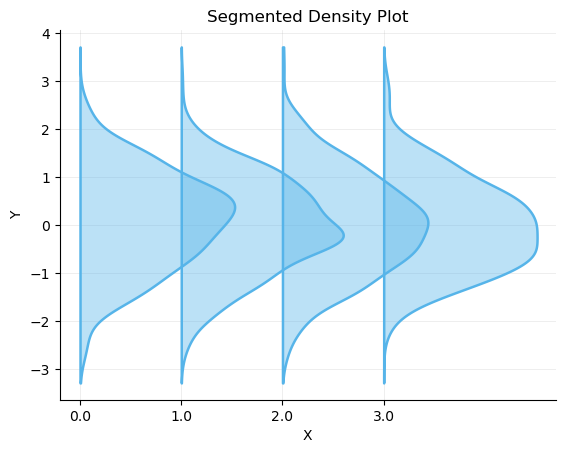

In [44]:
# Alternative: Segmented Density Plot
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(type="segmented_density", suggest=False)
plt.show()

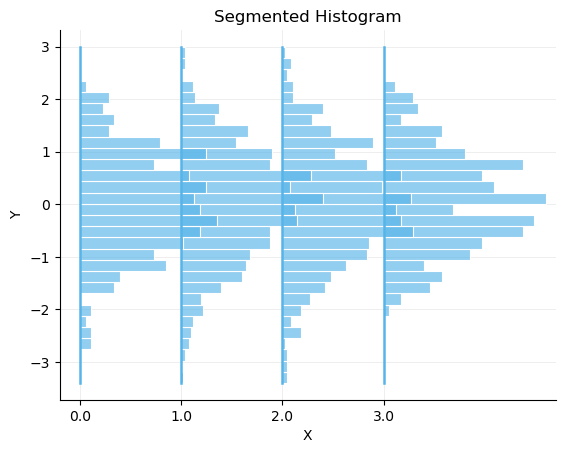

In [45]:
# Alternative: Segmented Histogram
RV(Binomial(3, 0.5) * Normal(0, 1)).sim(2000).plot(type="segmented_hist", suggest=False)
plt.show()

## 6. 1D categorical (string outcomes)

| | Default | Alternatives |
|---|---|---|
| **Small n** (n = 30) | Dot Plot | Bar Chart, Impulse Plot |
| **Large n** (n = 2000) | Bar Chart | Dot Plot, Impulse Plot |

String-valued RVs currently get `dim=None`, so `.plot()` skips the 1D dispatch entirely
and never reaches this configuration. Of the types the table lists here, only the bar
chart renders on strings today (`dotplot` and `impulse` raise on non-numeric data). So we
call `make_bar` directly on the simulated values, which is exactly what the integrated
`.plot()` will call once string RVs are routed here.

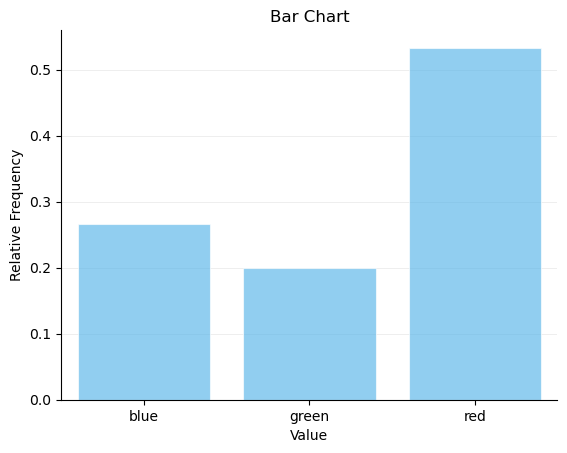

In [46]:
# Categorical bar chart, n = 30 (make_bar directly on string outcomes)
colors = np.array(RV(BoxModel(["red", "green", "blue"])).sim(30).results)
ax = plt.gca()
make_bar(colors, ax, get_next_color(ax))
plt.show()

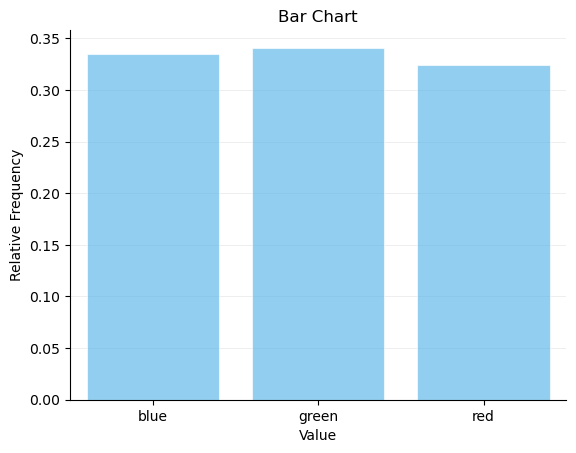

In [47]:
# Categorical bar chart, n = 2000 (make_bar directly on string outcomes)
colors = np.array(RV(BoxModel(["red", "green", "blue"])).sim(2000).results)
ax = plt.gca()
make_bar(colors, ax, get_next_color(ax))
plt.show()

## Known gaps between the table and `.plot()`

These are places where the lookup table promises a plot the dispatch can't currently
deliver — surfaced here so they aren't mistaken for notebook errors:

1. **`violin` in the `1D_continuous` alternatives has no 1D dispatch branch.** The 1D
   `.plot()` handles `dotplot`, `density`, `hist`, `bar`, `impulse`, `box`, `rug`, and
   `ecdf`, but not `violin`, so `.plot(type="violin")` on 1D data draws an empty plot.
   Either add a single-violin branch to the 1D dispatch or drop `violin` from the two
   `1D_continuous` rows.
2. **The `1D_categorical` rows aren't reachable via `.plot()`.** String RVs get
   `dim=None` and skip the 1D dispatch, and `dotplot` / `impulse` (listed alternatives)
   raise on non-numeric data — only `make_bar` works on strings. Routing string RVs to a
   `1D_categorical` config is a separate change to `RVResults` dimension handling.

## Verification checklist

- [ ] Every configuration shows its small-n and large-n **default** (no `type=`), and
  the printed suggestion note names the default + alternatives from the table
- [ ] Every **alternative** the table lists renders (except the two documented gaps)
- [ ] Defaults shift correctly from small n to large n (e.g. 1D discrete dot plot →
  impulse; 1D continuous rug → histogram; 2D dd scatter → tile; 2D cc scatter →
  2D histogram; 2D mixed segmented rug → tile)
- [ ] 2D histogram `hex=True` draws a hexbin; 2D density `contour=True` draws banded
  contours
- [ ] Categorical bar chart renders at both n via `make_bar`
- [ ] No unexpected errors or empty plots